# LOAD DATASET

In [1]:
import pandas as pd

df = pd.read_csv("Customer Satisfaction_Sentiment Analysis.csv")
df

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,12942,Male,Loyal Customer,8,Personal Travel,Eco,563,3,5,...,1,5,4,5,5,4,1,35,21.0,neutral or dissatisfied
99996,99996,47237,Male,Loyal Customer,61,Personal Travel,Eco Plus,945,1,1,...,3,3,3,4,1,4,3,40,46.0,neutral or dissatisfied
99997,99997,41508,Male,Loyal Customer,43,Business travel,Business,1464,3,3,...,5,5,5,5,4,5,3,0,0.0,satisfied
99998,99998,107935,Female,disloyal Customer,22,Business travel,Business,611,4,2,...,3,2,5,4,1,3,3,15,6.0,neutral or dissatisfied


In [2]:
print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 100000
Jumlah Kolom : 25


# cek issue data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         100000 non-null  int64  
 1   id                                 100000 non-null  int64  
 2   Gender                             100000 non-null  object 
 3   Customer Type                      100000 non-null  object 
 4   Age                                100000 non-null  int64  
 5   Type of Travel                     100000 non-null  object 
 6   Class                              100000 non-null  object 
 7   Flight Distance                    100000 non-null  int64  
 8   Inflight wifi service              100000 non-null  int64  
 9   Departure/Arrival time convenient  100000 non-null  int64  
 10  Ease of Online booking             100000 non-null  int64  
 11  Gate location                      10000

In [4]:
# Cek missing value
df.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             300
satisfaction    

In [5]:
# Cek duplikat
print("Jumlah Duplicate :", df.duplicated().sum())

Jumlah Duplicate : 0


In [6]:
# Cek inkonsisten kategori
for col in df.select_dtypes(include='object'):
    print("\n", "="*50)
    print("Kolom :", col)
    print(df[col].unique())


Kolom : Gender
['Male' 'Female']

Kolom : Customer Type
['Loyal Customer' 'disloyal Customer']

Kolom : Type of Travel
['Personal Travel' 'Business travel']

Kolom : Class
['Eco Plus' 'Business' 'Eco']

Kolom : satisfaction
['neutral or dissatisfied' 'satisfied']


In [7]:
# Cek nilai yang tidak masuk akal khusus kolom numerik
import numpy as np
for col in df.select_dtypes(include=np.number):
    print("\n", col)
    print("Minimum :", df[col].min())
    print("Maximum :", df[col].max())


 Unnamed: 0
Minimum : 0
Maximum : 99999

 id
Minimum : 1
Maximum : 129880

 Age
Minimum : 7
Maximum : 85

 Flight Distance
Minimum : 31
Maximum : 4983

 Inflight wifi service
Minimum : 0
Maximum : 5

 Departure/Arrival time convenient
Minimum : 0
Maximum : 5

 Ease of Online booking
Minimum : 0
Maximum : 5

 Gate location
Minimum : 0
Maximum : 5

 Food and drink
Minimum : 0
Maximum : 5

 Online boarding
Minimum : 0
Maximum : 5

 Seat comfort
Minimum : 0
Maximum : 5

 Inflight entertainment
Minimum : 0
Maximum : 5

 On-board service
Minimum : 0
Maximum : 5

 Leg room service
Minimum : 0
Maximum : 5

 Baggage handling
Minimum : 1
Maximum : 5

 Checkin service
Minimum : 0
Maximum : 5

 Inflight service
Minimum : 0
Maximum : 5

 Cleanliness
Minimum : 0
Maximum : 5

 Departure Delay in Minutes
Minimum : 0
Maximum : 1592

 Arrival Delay in Minutes
Minimum : 0.0
Maximum : 1584.0


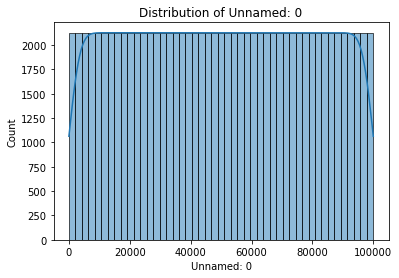

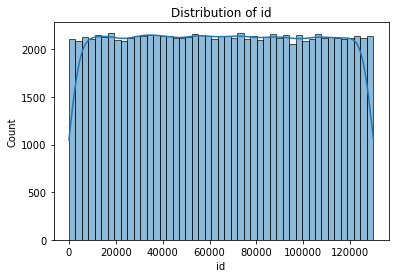

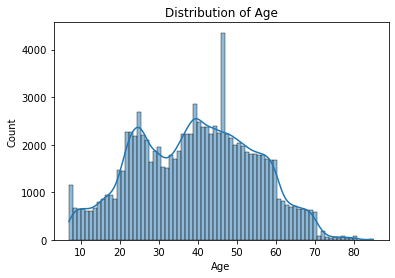

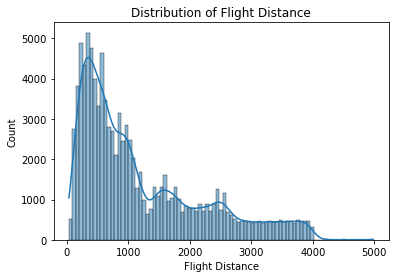

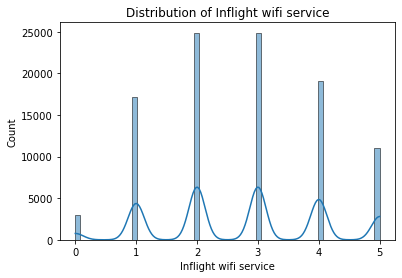

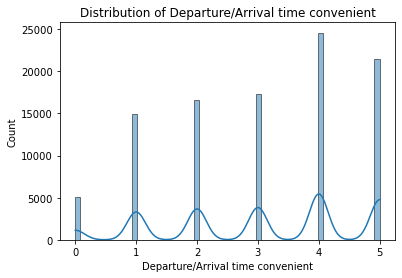

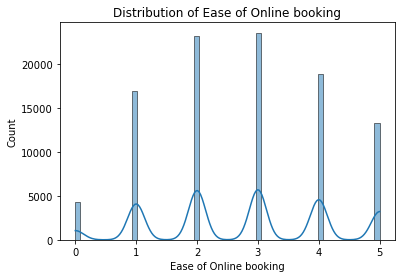

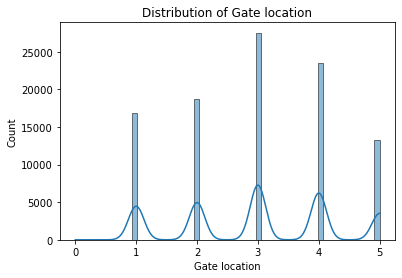

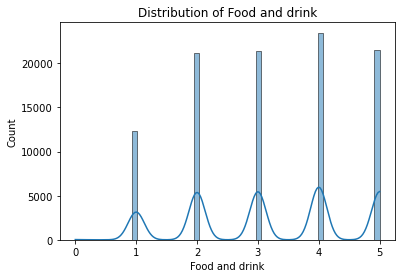

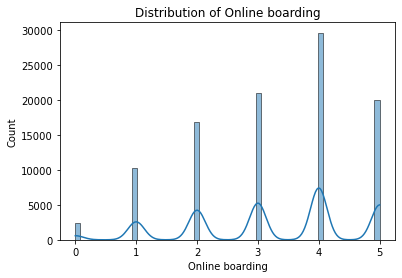

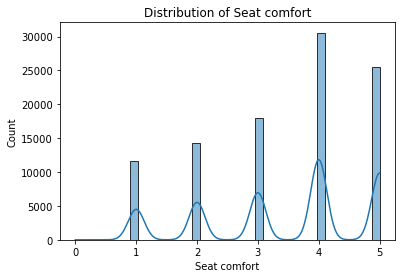

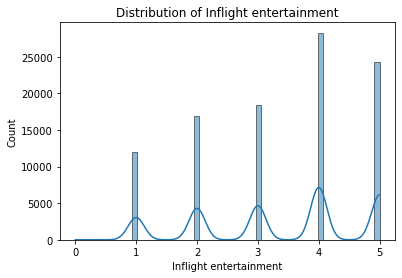

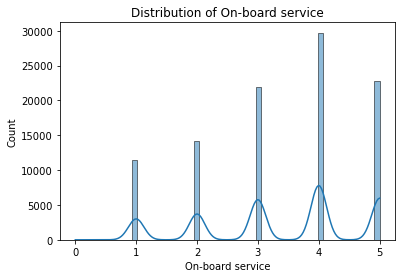

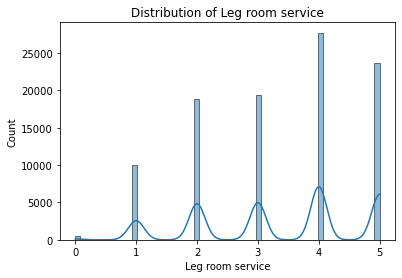

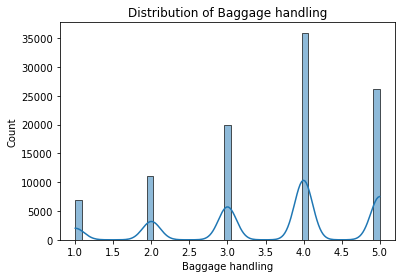

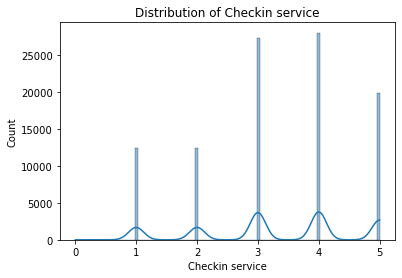

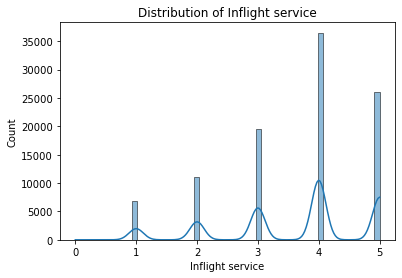

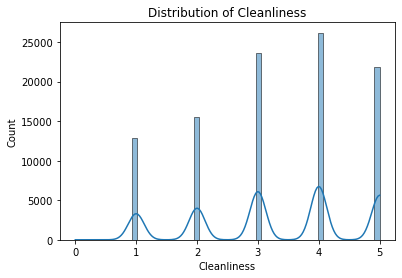

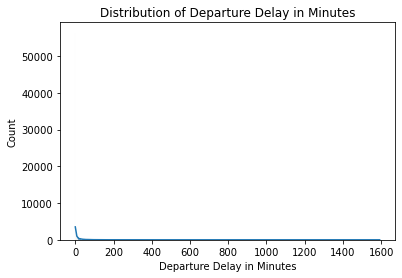

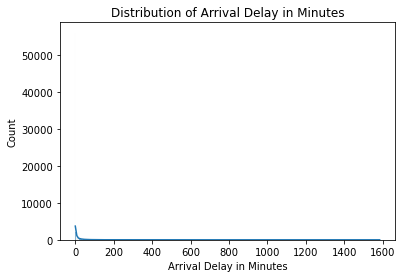

In [8]:
# Cek distribusi numerikal
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f'Distribution of {col}')
    
    plt.show()

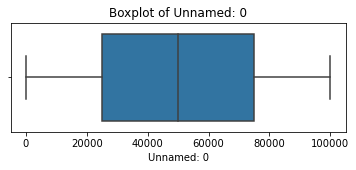

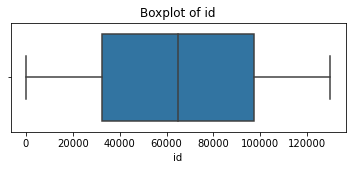

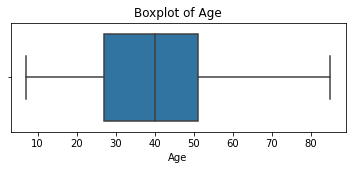

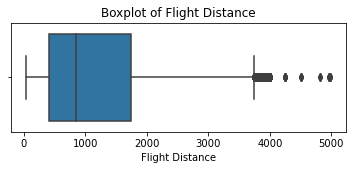

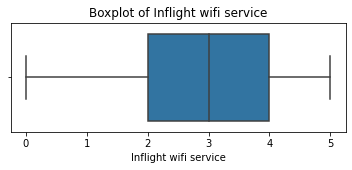

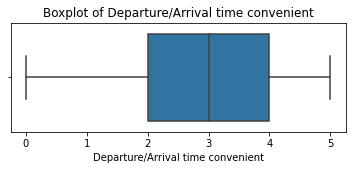

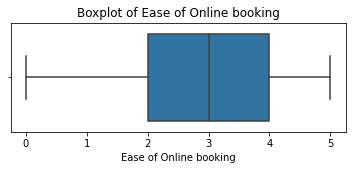

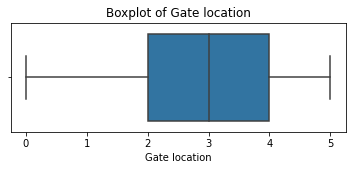

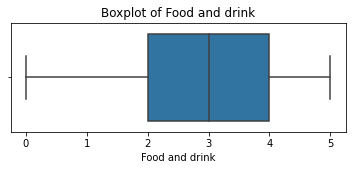

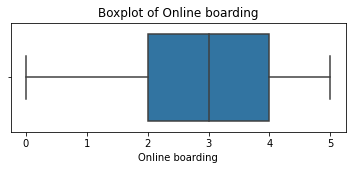

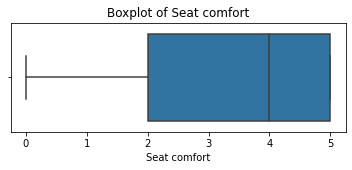

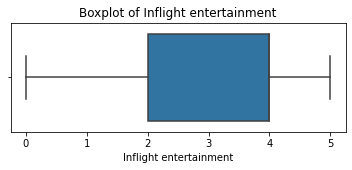

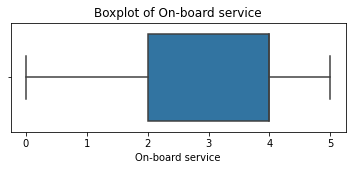

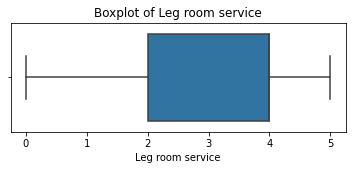

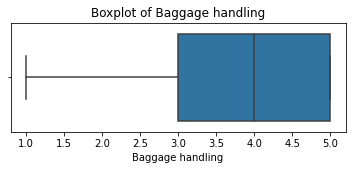

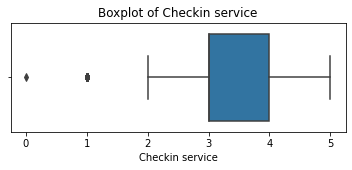

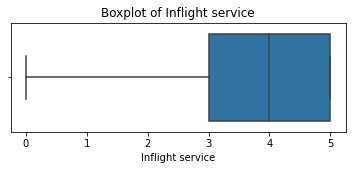

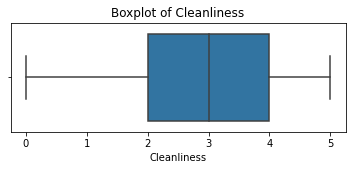

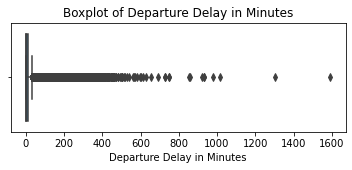

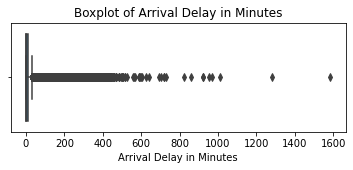

In [9]:
# cek outlier secara visual
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:

    plt.figure(figsize=(6,2))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

In [10]:
# Cek outlier secara IQR
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    outlier = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    pct = len(outlier)/len(df)*100

    print(f"{col}: {pct:.2f}%")

Unnamed: 0: 0.00%
id: 0.00%
Age: 0.00%
Flight Distance: 2.19%
Inflight wifi service: 0.00%
Departure/Arrival time convenient: 0.00%
Ease of Online booking: 0.00%
Gate location: 0.00%
Food and drink: 0.00%
Online boarding: 0.00%
Seat comfort: 0.00%
Inflight entertainment: 0.00%
On-board service: 0.00%
Leg room service: 0.00%
Baggage handling: 0.00%
Checkin service: 12.40%
Inflight service: 0.00%
Cleanliness: 0.00%
Departure Delay in Minutes: 14.02%
Arrival Delay in Minutes: 13.47%


# Data Cleaning

## 1. hapus kolom yang tidak diperlukan

In [11]:
# Menghapus kolom index yang tidak diperlukan
df.drop(columns=['Unnamed: 0'], inplace=True)

## 2. handle missing value

In [12]:
# Cek korelasi Departure Delay in Minutes dengan Arrival Delay in Minutes 
df[['Departure Delay in Minutes',
    'Arrival Delay in Minutes']].corr()

,Departure Delay in Minutes,Arrival Delay in Minutes
Departure Delay in Minutes,1.000000,0.965571
Arrival Delay in Minutes,0.965571,1.000000


In [13]:
# Cek selisih median
difference = (
    df['Arrival Delay in Minutes']
    - df['Departure Delay in Minutes']
)

difference.describe()

count    99700.000000
mean         0.428897
std         10.089519
min        -51.000000
25%         -2.000000
50%          0.000000
75%          0.000000
max        209.000000
dtype: float64

In [14]:
# Mengisi missing value Arrival Delay dengan nilai Departure Delay

mask = df['Arrival Delay in Minutes'].isna()

df.loc[mask, 'Arrival Delay in Minutes'] = df.loc[mask, 'Departure Delay in Minutes']

In [15]:
# Cek ulang missing
df['Arrival Delay in Minutes'].isna().sum()

0

In [16]:
data = df.copy()

# Data Manipulation

## feature engineering 

1. Customer Experience Index (CEI)

In [17]:
service_columns = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

data['Customer Experience Index'] = data[service_columns].mean(axis=1)

2. Proxy NPS

In [18]:
def proxy_nps(score):
    if score >= 5:
        return "Promoter"
    elif score >= 4:
        return "Passive"
    else:
        return "Detractor"

data['Proxy NPS Category'] = data['Customer Experience Index'].apply(proxy_nps)

In [19]:
promoter = (data['Proxy NPS Category']=="Promoter").mean()*100

detractor = (data['Proxy NPS Category']=="Detractor").mean()*100

proxy_nps = promoter-detractor

print(proxy_nps)

-85.30099999999999


3. Delay Status

In [20]:
data['Delay Status'] = data['Arrival Delay in Minutes'].apply(
    lambda x: 'Delayed' if x > 0 else 'On Time'
)

4. Delay Severity

In [21]:
def delay_category(delay):

    if delay == 0:
        return 'On Time'

    elif delay <=15:
        return 'Minor Delay'

    elif delay<=60:
        return 'Moderate Delay'

    else:
        return 'Severe Delay'

data['Delay Severity'] = data['Arrival Delay in Minutes'].apply(delay_category)

5. Long Distance Flight

In [22]:
def flight_distance(distance):

    if distance <1000:
        return 'Short'

    elif distance<3000:
        return 'Medium'

    else:
        return 'Long'

data['Flight Distance Category'] = data['Flight Distance'].apply(flight_distance)

6. Total Delay

In [23]:
data['Total Delay'] = (
    data['Departure Delay in Minutes'] +
    data['Arrival Delay in Minutes']
)

7. Delay Difference

In [24]:
data['Delay Difference'] = (
    data['Arrival Delay in Minutes']
    -
    data['Departure Delay in Minutes']
)

8. Service Consistency

In [25]:
data['Service Consistency'] = data[service_columns].std(axis=1)

9. Premium Customer

In [26]:
data['Premium Customer'] = (
    (data['Class']=='Business')
    &
    (data['Customer Type']=='Loyal Customer')
)

10. Customer Age Group 

In [27]:
def age_group(age):

    if age<25:
        return 'Young'

    elif age<40:
        return 'Adult'

    elif age<60:
        return 'Middle Age'

    else:
        return 'Senior'

data['Age Group']=data['Age'].apply(age_group)

11. High Satisfaction Customer

In [28]:
data['Experience Level']=data['Customer Experience Index'].apply(

lambda x:
'High'
if x>=4
else 'Low'
)

12. CSAT Score

In [29]:
data['CSAT Score'] = data['satisfaction'].map({
    'satisfied':100,
    'neutral or dissatisfied':0
})

# EDA (Exploratory Data Analysis)

## DATASET OVERVIEW

In [30]:
# ==========================================================
# DATASET OVERVIEW
# Tujuan:
# Memahami struktur dataset, jumlah data, tipe data,
# dan keberadaan missing value pada setiap kolom.
# ==========================================================

# Menampilkan informasi umum dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 100000 non-null  int64  
 1   Gender                             100000 non-null  object 
 2   Customer Type                      100000 non-null  object 
 3   Age                                100000 non-null  int64  
 4   Type of Travel                     100000 non-null  object 
 5   Class                              100000 non-null  object 
 6   Flight Distance                    100000 non-null  int64  
 7   Inflight wifi service              100000 non-null  int64  
 8   Departure/Arrival time convenient  100000 non-null  int64  
 9   Ease of Online booking             100000 non-null  int64  
 10  Gate location                      100000 non-null  int64  
 11  Food and drink                     10000

In [31]:
# ==========================================================
# Menampilkan jumlah baris dan kolom dataset
# ==========================================================

print(f"Jumlah Baris  : {data.shape[0]}")
print(f"Jumlah Kolom  : {data.shape[1]}")

Jumlah Baris  : 100000
Jumlah Kolom  : 36


## MISSING VALUE

In [32]:
# ==========================================================
# MISSING VALUE ANALYSIS
# Tujuan:
# Mengidentifikasi jumlah dan persentase missing value
# pada setiap kolom.
# ==========================================================

missing = pd.DataFrame({
    'Missing Value': data.isnull().sum(),
    'Percentage (%)': round((data.isnull().sum()/len(data))*100,2)
})

missing.sort_values(
    by='Missing Value',
    ascending=False
)

,Missing Value,Percentage (%)
id,0,0.0
Gender,0,0.0
Cleanliness,0,0.0
Departure Delay in Minutes,0,0.0
Arrival Delay in Minutes,0,0.0
satisfaction,0,0.0
Customer Experience Index,0,0.0
Proxy NPS Category,0,0.0
Delay Status,0,0.0
Delay Severity,0,0.0


In [33]:
# ==========================================================
# DEFINE COLUMN GROUPS
# Tujuan:
# Mengelompokkan kolom berdasarkan jenis analisis
# agar memudahkan proses EDA dan visualisasi.
# ==========================================================

service_columns = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

categorical_columns = [
    'Gender',
    'Customer Type',
    'Type of Travel',
    'Class',
    'satisfaction',
    'Proxy NPS Category',
    'Delay Status',
    'Delay Severity',
    'Flight Distance Category',
    'Age Group',
    'Experience Level',
    'Premium Customer'
]

numerical_columns = [
    'Age',
    'Flight Distance',
    'Departure Delay in Minutes',
    'Arrival Delay in Minutes',
    'Customer Experience Index',
    'Total Delay',
    'Delay Difference',
    'Service Consistency',
    'CSAT Score'
]

## UNIVARIATE ANALYSIS

Female    50714
Male      49286
Name: Gender, dtype: int64


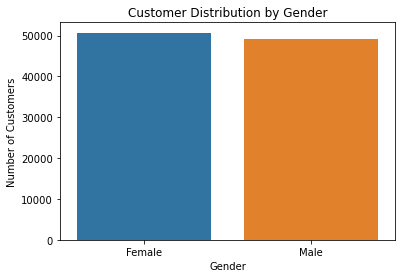

In [34]:
# ==========================================================
# CUSTOMER DEMOGRAPHIC OVERVIEW
# Distribution of Gender
#
# Tujuan:
# Melihat distribusi pelanggan berdasarkan jenis kelamin.
#
# Alasan:
# Analisis ini membantu mengetahui apakah pelanggan didominasi
# oleh laki-laki atau perempuan sehingga perusahaan dapat
# memahami komposisi pelanggan secara umum.
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns
# Menampilkan jumlah setiap kategori gender
gender_count = data['Gender'].value_counts()

print(gender_count)

# Visualisasi distribusi gender
plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x='Gender',
    order=gender_count.index
)

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

Loyal Customer       81713
disloyal Customer    18287
Name: Customer Type, dtype: int64


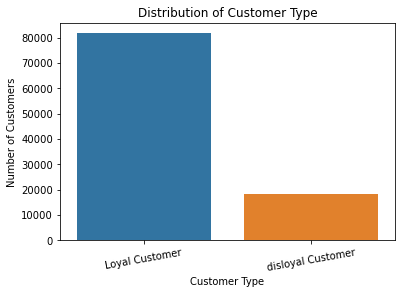

In [35]:
# ==========================================================
# CUSTOMER DEMOGRAPHIC OVERVIEW
# Distribution of Customer Type
#
# Tujuan:
# Mengetahui proporsi Loyal Customer dan Disloyal Customer.
#
# Alasan:
# Loyal customer merupakan aset penting perusahaan karena
# memiliki peluang lebih besar untuk melakukan pembelian
# berulang dibandingkan pelanggan baru.
# ==========================================================

customer_type = data['Customer Type'].value_counts()

print(customer_type)

plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x='Customer Type',
    order=customer_type.index
)

plt.title('Distribution of Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')

plt.xticks(rotation=10)

plt.show()

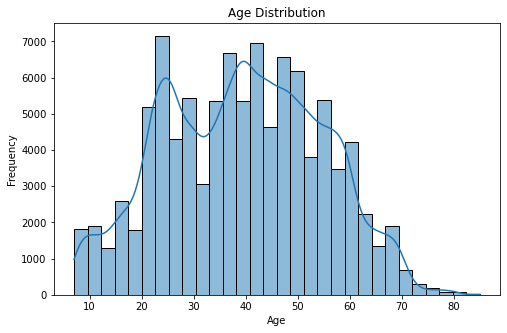

In [36]:
# ==========================================================
# CUSTOMER DEMOGRAPHIC OVERVIEW
# Distribution of Customer Age
#
# Tujuan:
# Melihat persebaran usia pelanggan.
#
# Alasan:
# Analisis usia membantu mengidentifikasi kelompok umur yang
# paling banyak menggunakan layanan maskapai.
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x='Age',
    bins=30,
    kde=True
)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

Middle Age    41182
Adult         30398
Young         19069
Senior         9351
Name: Age Group, dtype: int64


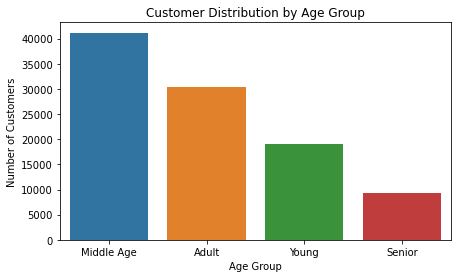

In [37]:
# ==========================================================
# CUSTOMER DEMOGRAPHIC OVERVIEW
# Distribution of Age Group
#
# Tujuan:
# Mengetahui kelompok usia pelanggan.
#
# Alasan:
# Segmentasi usia lebih mudah dipahami dibandingkan melihat
# usia dalam bentuk angka sehingga memudahkan analisis bisnis.
# ==========================================================

age_group = data['Age Group'].value_counts()

print(age_group)

plt.figure(figsize=(7,4))

sns.countplot(
    data=data,
    x='Age Group',
    order=age_group.index
)

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.show()

Business travel    68977
Personal Travel    31023
Name: Type of Travel, dtype: int64


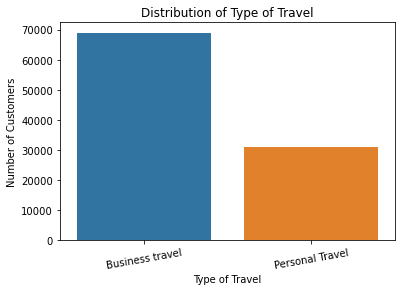

In [38]:
# ==========================================================
# TRAVEL CHARACTERISTICS
# Distribution of Type of Travel
#
# Tujuan:
# Mengetahui tujuan utama perjalanan pelanggan.
#
# Alasan:
# Mengetahui apakah pelanggan lebih banyak melakukan
# perjalanan bisnis atau perjalanan pribadi.
# ==========================================================

travel_type = data['Type of Travel'].value_counts()

print(travel_type)

plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x='Type of Travel',
    order=travel_type.index
)

plt.title('Distribution of Type of Travel')
plt.xlabel('Type of Travel')
plt.ylabel('Number of Customers')

plt.xticks(rotation=10)

plt.show()

Business    47806
Eco         44998
Eco Plus     7196
Name: Class, dtype: int64


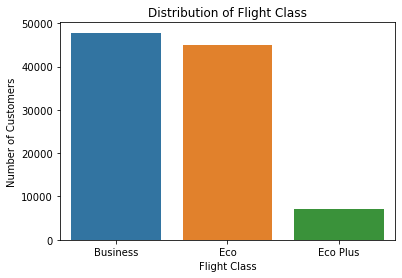

In [39]:
# ==========================================================
# TRAVEL CHARACTERISTICS
# Distribution of Flight Class
#
# Tujuan:
# Mengetahui kelas penerbangan yang paling banyak digunakan.
#
# Alasan:
# Flight Class sering berkaitan dengan kualitas layanan
# serta tingkat kepuasan pelanggan.
# ==========================================================

flight_class = data['Class'].value_counts()

print(flight_class)

plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x='Class',
    order=flight_class.index
)

plt.title('Distribution of Flight Class')
plt.xlabel('Flight Class')
plt.ylabel('Number of Customers')

plt.show()

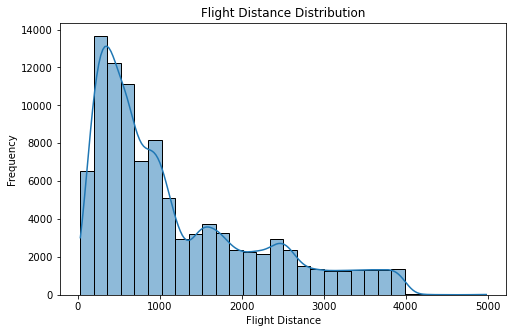

In [40]:
# ==========================================================
# TRAVEL CHARACTERISTICS
# Distribution of Flight Distance
#
# Tujuan:
# Melihat persebaran jarak penerbangan pelanggan.
#
# Alasan:
# Flight Distance dapat mempengaruhi pengalaman pelanggan,
# terutama terhadap kenyamanan, hiburan, maupun layanan
# selama penerbangan.
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x='Flight Distance',
    bins=30,
    kde=True
)

plt.title('Flight Distance Distribution')
plt.xlabel('Flight Distance')
plt.ylabel('Frequency')

plt.show()

In [41]:
# ==========================================================
# FLIGHT DISTANCE STATISTICS
#
# Tujuan:
# Menampilkan statistik deskriptif Flight Distance.
#
# Alasan:
# Memberikan gambaran numerik mengenai rata-rata,
# median, nilai minimum, maksimum, dan penyebaran
# jarak penerbangan pelanggan.
# ==========================================================

data['Flight Distance'].describe()

count    100000.00000
mean       1190.58611
std         997.24029
min          31.00000
25%         414.00000
50%         844.00000
75%        1744.00000
max        4983.00000
Name: Flight Distance, dtype: float64

Short     57744
Medium    34283
Long       7973
Name: Flight Distance Category, dtype: int64


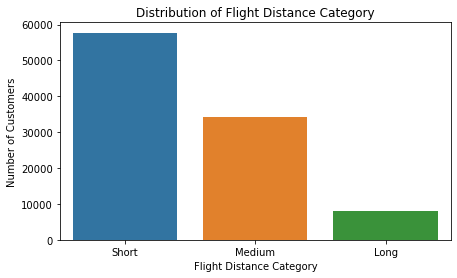

In [42]:
# ==========================================================
# TRAVEL CHARACTERISTICS
# Distribution of Flight Distance Category
#
# Tujuan:
# Mengelompokkan pelanggan berdasarkan kategori
# jarak penerbangan.
#
# Alasan:
# Segmentasi jarak penerbangan memudahkan analisis
# dibandingkan menggunakan angka mentah.
# ==========================================================

distance_category = data['Flight Distance Category'].value_counts()

print(distance_category)

plt.figure(figsize=(7,4))

sns.countplot(
    data=data,
    x='Flight Distance Category',
    order=distance_category.index
)

plt.title('Distribution of Flight Distance Category')
plt.xlabel('Flight Distance Category')
plt.ylabel('Number of Customers')

plt.show()

Inflight service                     3.64012
Baggage handling                     3.63193
Seat comfort                         3.44034
On-board service                     3.38223
Inflight entertainment               3.35818
Leg room service                     3.35056
Checkin service                      3.30382
Cleanliness                          3.28726
Online boarding                      3.25076
Food and drink                       3.20331
Departure/Arrival time convenient    3.05913
Gate location                        2.97566
Ease of Online booking               2.75604
Inflight wifi service                2.72882
dtype: float64

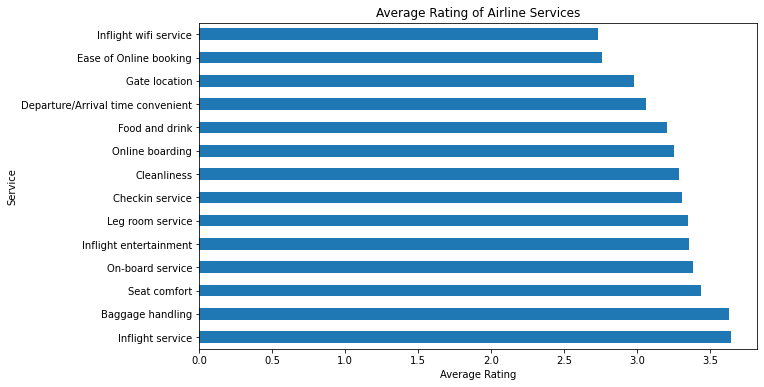

In [43]:
# ==========================================================
# SERVICE PERFORMANCE ANALYSIS
# Average Rating of Each Service
#
# Tujuan:
# Mengetahui rata-rata penilaian setiap layanan maskapai.
#
# Alasan:
# Membantu mengidentifikasi layanan dengan performa terbaik
# maupun layanan yang perlu menjadi prioritas perbaikan.
# ==========================================================

service_columns = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

service_mean = (
    data[service_columns]
    .mean()
    .sort_values(ascending=False)
)

display(service_mean)

plt.figure(figsize=(10,6))

service_mean.plot(kind='barh')

plt.title('Average Rating of Airline Services')
plt.xlabel('Average Rating')
plt.ylabel('Service')

plt.show()

In [44]:
# ==========================================================
# TOP 5 BEST SERVICES
#
# Tujuan:
# Mengetahui lima layanan dengan rata-rata penilaian tertinggi.
#
# Alasan:
# Mengidentifikasi kekuatan utama layanan maskapai yang perlu
# dipertahankan kualitasnya.
# ==========================================================

top5 = service_mean.head(5)

display(top5)

Inflight service          3.64012
Baggage handling          3.63193
Seat comfort              3.44034
On-board service          3.38223
Inflight entertainment    3.35818
dtype: float64

In [45]:
# ==========================================================
# TOP 5 LOWEST SERVICES
#
# Tujuan:
# Mengetahui lima layanan dengan rata-rata penilaian terendah.
#
# Alasan:
# Mengidentifikasi area layanan yang perlu diprioritaskan
# untuk dilakukan perbaikan.
# ==========================================================

bottom5 = service_mean.tail(5)

display(bottom5)

Food and drink                       3.20331
Departure/Arrival time convenient    3.05913
Gate location                        2.97566
Ease of Online booking               2.75604
Inflight wifi service                2.72882
dtype: float64

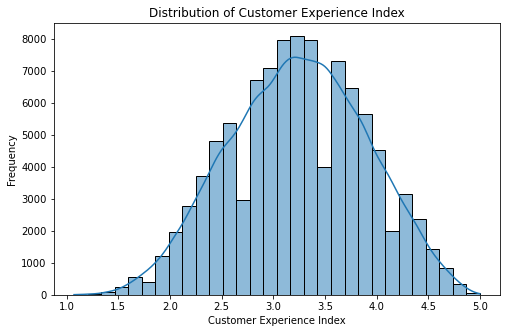

In [46]:
# ==========================================================
# CUSTOMER EXPERIENCE INDEX (CEI)
#
# Tujuan:
# Melihat distribusi skor pengalaman pelanggan secara
# keseluruhan.
#
# Alasan:
# CEI merupakan representasi dari kualitas pengalaman
# pelanggan berdasarkan rata-rata seluruh layanan.
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x='Customer Experience Index',
    bins=30,
    kde=True
)

plt.title('Distribution of Customer Experience Index')
plt.xlabel('Customer Experience Index')
plt.ylabel('Frequency')

plt.show()

In [47]:
# ==========================================================
# CUSTOMER EXPERIENCE INDEX STATISTICS
#
# Tujuan:
# Menampilkan statistik deskriptif CEI.
#
# Alasan:
# Memberikan gambaran umum mengenai tingkat pengalaman
# pelanggan secara keseluruhan.
# ==========================================================

data['Customer Experience Index'].describe()

count    100000.000000
mean          3.240583
std           0.661837
min           1.071429
25%           2.785714
50%           3.285714
75%           3.714286
max           5.000000
Name: Customer Experience Index, dtype: float64

neutral or dissatisfied    56665
satisfied                  43335
Name: satisfaction, dtype: int64


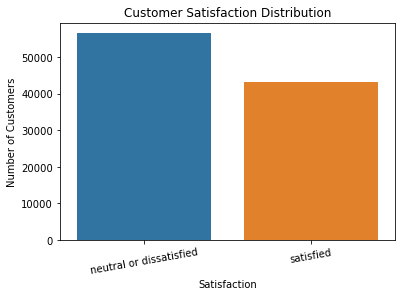

In [48]:
# ==========================================================
# CUSTOMER SATISFACTION OVERVIEW
# Distribution of Customer Satisfaction
#
# Tujuan:
# Mengetahui distribusi pelanggan yang puas dan
# tidak puas terhadap layanan maskapai.
#
# Alasan:
# Customer Satisfaction merupakan target utama
# dalam analisis sehingga perlu dipahami terlebih dahulu
# sebelum mencari faktor-faktor yang mempengaruhinya.
# ==========================================================

satisfaction = data['satisfaction'].value_counts()

print(satisfaction)

plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x='satisfaction',
    order=satisfaction.index
)

plt.title('Customer Satisfaction Distribution')
plt.xlabel('Satisfaction')
plt.ylabel('Number of Customers')

plt.xticks(rotation=10)

plt.show()

In [49]:
# ==========================================================
# CUSTOMER SATISFACTION SUMMARY
#
# Tujuan:
# Menampilkan jumlah dan persentase setiap kategori
# kepuasan pelanggan.
# ==========================================================

summary = pd.DataFrame({

    'Count':data['satisfaction'].value_counts(),

    'Percentage (%)':
    round(data['satisfaction'].value_counts(normalize=True)*100,2)

})

display(summary)

,Count,Percentage (%)
neutral or dissatisfied,56665,56.66
satisfied,43335,43.34


In [50]:
# ==========================================================
# CUSTOMER SATISFACTION SCORE (CSAT)
#
# Tujuan:
# Menghitung persentase pelanggan yang merasa puas.
#
# Rumus:
# CSAT = (Jumlah Satisfied / Total Customer) x 100%
#
# Alasan:
# CSAT merupakan salah satu Key Performance Indicator (KPI)
# yang umum digunakan untuk mengukur tingkat kepuasan pelanggan.
# ==========================================================

csat = (
    data['CSAT Score'].sum() /
    (len(data)*100)
)*100

print(f"CSAT Score : {csat:.2f}%")

CSAT Score : 43.34%


Low     85308
High    14692
Name: Experience Level, dtype: int64


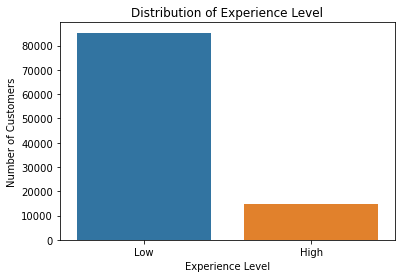

In [51]:
# ==========================================================
# EXPERIENCE LEVEL DISTRIBUTION
#
# Tujuan:
# Mengetahui distribusi pelanggan berdasarkan
# Customer Experience Index (CEI).
#
# Alasan:
# Membantu melihat apakah sebagian besar pelanggan
# memiliki pengalaman yang tinggi atau rendah.
# ==========================================================

experience = data['Experience Level'].value_counts()

print(experience)

plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x='Experience Level',
    order=experience.index
)

plt.title('Distribution of Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Number of Customers')

plt.show()

Detractor    85308
Passive      14685
Promoter         7
Name: Proxy NPS Category, dtype: int64


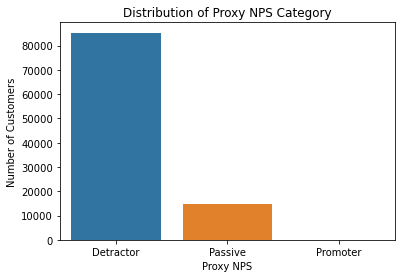

In [52]:
# ==========================================================
# PROXY NPS CATEGORY
#
# Tujuan:
# Mengetahui distribusi pelanggan berdasarkan
# kategori Proxy NPS.
#
# Alasan:
# Karena dataset tidak memiliki pertanyaan resmi
# Net Promoter Score (0-10), maka digunakan
# pendekatan (Proxy NPS) berdasarkan CEI.
# ==========================================================

proxy = data['Proxy NPS Category'].value_counts()

print(proxy)

plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x='Proxy NPS Category',
    order=proxy.index
)

plt.title('Distribution of Proxy NPS Category')
plt.xlabel('Proxy NPS')
plt.ylabel('Number of Customers')

plt.show()

In [53]:
# ==========================================================
# PROXY NET PROMOTER SCORE (Proxy NPS)
#
# Tujuan:
# Menghitung nilai Proxy Net Promoter Score.
#
# Rumus:
# Proxy NPS = %Promoter - %Detractor
#
# Catatan:
# Nilai ini merupakan pendekatan (Proxy),
# bukan Official Net Promoter Score,
# karena dataset tidak memiliki pertanyaan
# rekomendasi pelanggan (0-10).
# ==========================================================

promoter = (
    data['Proxy NPS Category']
    .eq('Promoter')
    .mean()*100
)

detractor = (
    data['Proxy NPS Category']
    .eq('Detractor')
    .mean()*100
)

proxy_nps = promoter-detractor

print(f"Proxy NPS : {proxy_nps:.2f}")

Proxy NPS : -85.30


In [54]:
# ==========================================================
# CUSTOMER SATISFACTION KPI
#
# Tujuan:
# Menampilkan KPI utama Customer Experience
# dalam bentuk ringkasan.
# ==========================================================

print("="*40)

print(f"CSAT Score                 : {csat:.2f}%")

print(f"Average CEI               : {data['Customer Experience Index'].mean():.2f}")

print(f"Proxy NPS                 : {proxy_nps:.2f}")

print("="*40)

CSAT Score                 : 43.34%
Average CEI               : 3.24
Proxy NPS                 : -85.30


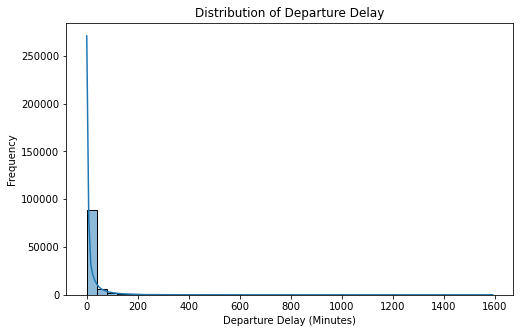

In [55]:
# ==========================================================
# OPERATIONAL PERFORMANCE ANALYSIS
# Distribution of Departure Delay
#
# Tujuan:
# Melihat distribusi keterlambatan keberangkatan.
#
# Alasan:
# Keterlambatan keberangkatan merupakan salah satu
# indikator performa operasional maskapai.
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x='Departure Delay in Minutes',
    bins=40,
    kde=True
)

plt.title('Distribution of Departure Delay')
plt.xlabel('Departure Delay (Minutes)')
plt.ylabel('Frequency')

plt.show()

In [56]:
# ==========================================================
# DEPARTURE DELAY STATISTICS
#
# Tujuan:
# Menampilkan statistik deskriptif keterlambatan
# keberangkatan.
# ==========================================================

data['Departure Delay in Minutes'].describe()

count    100000.000000
mean         14.823680
std          38.206983
min           0.000000
25%           0.000000
50%           0.000000
75%          12.000000
max        1592.000000
Name: Departure Delay in Minutes, dtype: float64

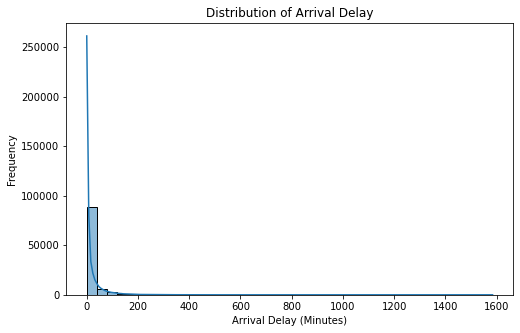

In [57]:
# ==========================================================
# ARRIVAL DELAY DISTRIBUTION
#
# Tujuan:
# Melihat distribusi keterlambatan kedatangan.
#
# Alasan:
# Mengetahui bagaimana performa maskapai dalam
# menjaga ketepatan waktu hingga tujuan akhir.
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x='Arrival Delay in Minutes',
    bins=40,
    kde=True
)

plt.title('Distribution of Arrival Delay')
plt.xlabel('Arrival Delay (Minutes)')
plt.ylabel('Frequency')

plt.show()

In [58]:
# ==========================================================
# ARRIVAL DELAY STATISTICS
#
# Tujuan:
# Menampilkan statistik deskriptif keterlambatan
# kedatangan.
# ==========================================================

data['Arrival Delay in Minutes'].describe()

count    100000.000000
mean         15.251290
std          38.785059
min           0.000000
25%           0.000000
50%           0.000000
75%          13.000000
max        1584.000000
Name: Arrival Delay in Minutes, dtype: float64

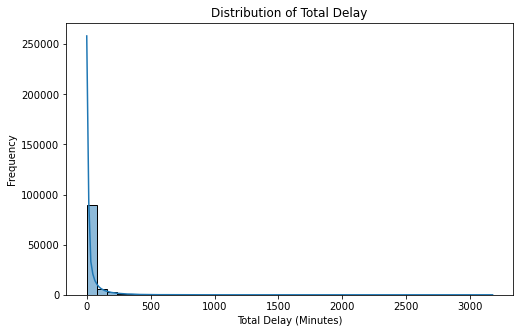

In [59]:
# ==========================================================
# TOTAL DELAY DISTRIBUTION
#
# Tujuan:
# Melihat distribusi total keterlambatan penerbangan.
#
# Alasan:
# Total Delay merupakan gabungan keterlambatan
# keberangkatan dan kedatangan sehingga memberikan
# gambaran performa operasional secara keseluruhan.
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x='Total Delay',
    bins=40,
    kde=True
)

plt.title('Distribution of Total Delay')
plt.xlabel('Total Delay (Minutes)')
plt.ylabel('Frequency')

plt.show()

On Time    56046
Delayed    43954
Name: Delay Status, dtype: int64


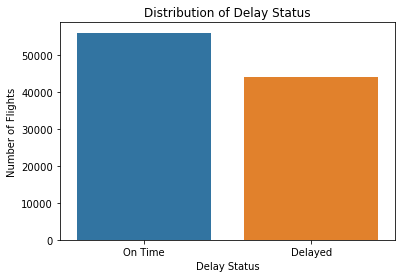

In [60]:
# ==========================================================
# DELAY STATUS
#
# Tujuan:
# Mengetahui proporsi penerbangan yang tepat waktu
# dan mengalami keterlambatan.
#
# Alasan:
# Mempermudah interpretasi performa operasional
# dibandingkan hanya melihat angka delay.
# ==========================================================

delay_status = data['Delay Status'].value_counts()

print(delay_status)

plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x='Delay Status',
    order=delay_status.index
)

plt.title('Distribution of Delay Status')
plt.xlabel('Delay Status')
plt.ylabel('Number of Flights')

plt.show()

On Time           56046
Minor Delay       21020
Moderate Delay    15819
Severe Delay       7115
Name: Delay Severity, dtype: int64


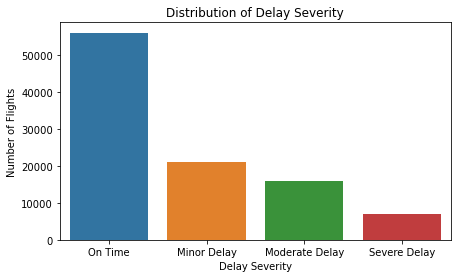

In [61]:
# ==========================================================
# DELAY SEVERITY
#
# Tujuan:
# Mengetahui tingkat keparahan keterlambatan.
#
# Alasan:
# Mengelompokkan delay menjadi beberapa kategori
# agar lebih mudah dipahami oleh pengguna bisnis.
# ==========================================================

delay_severity = data['Delay Severity'].value_counts()

print(delay_severity)

plt.figure(figsize=(7,4))

sns.countplot(
    data=data,
    x='Delay Severity',
    order=delay_severity.index
)

plt.title('Distribution of Delay Severity')
plt.xlabel('Delay Severity')
plt.ylabel('Number of Flights')

plt.show()

In [62]:
# ==========================================================
# OPERATIONAL PERFORMANCE SUMMARY
#
# Tujuan:
# Menampilkan jumlah dan persentase setiap kategori
# Delay Status dan Delay Severity.
# ==========================================================

for col in ['Delay Status', 'Delay Severity']:

    print("="*60)
    print(f"\n{col}\n")

    summary = pd.DataFrame({
        'Count': data[col].value_counts(),
        'Percentage (%)': round(data[col].value_counts(normalize=True)*100, 2)
    })

    display(summary)


Delay Status



,Count,Percentage (%)
On Time,56046,56.05
Delayed,43954,43.95



Delay Severity



,Count,Percentage (%)
On Time,56046,56.05
Minor Delay,21020,21.02
Moderate Delay,15819,15.82
Severe Delay,7115,7.12


## BIVARIATE ANALYSIS

satisfaction,neutral or dissatisfied,satisfied
Gender,,
Female,29070,21644
Male,27595,21691


satisfaction,neutral or dissatisfied,satisfied
Gender,,
Female,57.32,42.68
Male,55.99,44.01


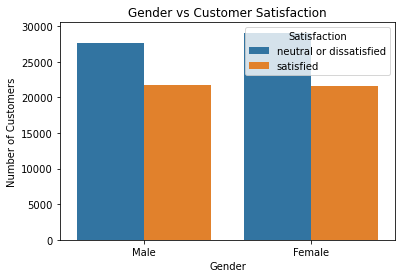

In [63]:
# ==========================================================
# BIVARIATE ANALYSIS
# Gender vs Customer Satisfaction
#
# Business Question:
# Apakah terdapat perbedaan tingkat kepuasan
# antara pelanggan laki-laki dan perempuan?
#
# Tujuan:
# Menganalisis distribusi kepuasan pelanggan
# berdasarkan gender.
# ==========================================================

# Crosstab jumlah
gender_sat = pd.crosstab(
    data['Gender'],
    data['satisfaction']
)

display(gender_sat)

# Crosstab persentase
gender_percent = pd.crosstab(
    data['Gender'],
    data['satisfaction'],
    normalize='index'
)*100

display(round(gender_percent,2))

# Visualisasi
plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x='Gender',
    hue='satisfaction'
)

plt.title('Gender vs Customer Satisfaction')

plt.xlabel('Gender')

plt.ylabel('Number of Customers')

plt.legend(title='Satisfaction')

plt.show()

satisfaction,neutral or dissatisfied,satisfied
Customer Type,,
Loyal Customer,42711,39002
disloyal Customer,13954,4333


satisfaction,neutral or dissatisfied,satisfied
Customer Type,,
Loyal Customer,52.27,47.73
disloyal Customer,76.31,23.69


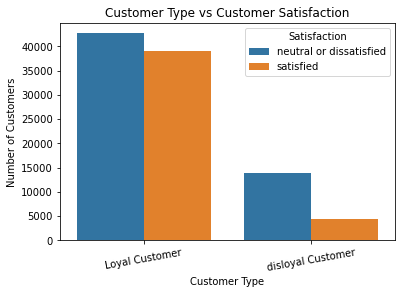

In [64]:
# ==========================================================
# BIVARIATE ANALYSIS
# Customer Type vs Satisfaction
#
# Business Question:
# Apakah Loyal Customer memiliki tingkat
# kepuasan lebih tinggi dibandingkan
# Disloyal Customer?
#
# Tujuan:
# Menganalisis hubungan Customer Type
# dengan Customer Satisfaction.
# ==========================================================

customer_sat = pd.crosstab(
    data['Customer Type'],
    data['satisfaction']
)

display(customer_sat)

customer_percent = pd.crosstab(
    data['Customer Type'],
    data['satisfaction'],
    normalize='index'
)*100

display(round(customer_percent,2))

plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x='Customer Type',
    hue='satisfaction'
)

plt.title('Customer Type vs Customer Satisfaction')

plt.xlabel('Customer Type')

plt.ylabel('Number of Customers')

plt.xticks(rotation=10)

plt.legend(title='Satisfaction')

plt.show()

satisfaction,neutral or dissatisfied,satisfied
Age Group,,
Adult,18569,11829
Middle Age,17427,23755
Senior,6824,2527
Young,13845,5224


satisfaction,neutral or dissatisfied,satisfied
Age Group,,
Adult,61.09,38.91
Middle Age,42.32,57.68
Senior,72.98,27.02
Young,72.60,27.40


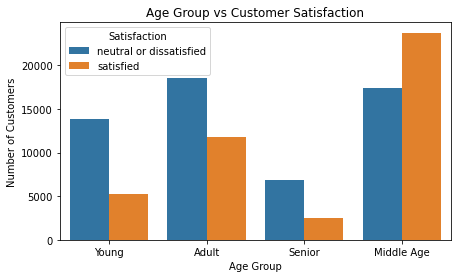

In [65]:
# ==========================================================
# BIVARIATE ANALYSIS
# Age Group vs Satisfaction
#
# Business Question:
# Kelompok usia mana yang memiliki
# tingkat kepuasan paling tinggi?
#
# Tujuan:
# Mengidentifikasi perbedaan tingkat
# kepuasan antar kelompok usia.
# ==========================================================

age_sat = pd.crosstab(
    data['Age Group'],
    data['satisfaction']
)

display(age_sat)

age_percent = pd.crosstab(
    data['Age Group'],
    data['satisfaction'],
    normalize='index'
)*100

display(round(age_percent,2))

plt.figure(figsize=(7,4))

sns.countplot(
    data=data,
    x='Age Group',
    hue='satisfaction'
)

plt.title('Age Group vs Customer Satisfaction')

plt.xlabel('Age Group')

plt.ylabel('Number of Customers')

plt.legend(title='Satisfaction')

plt.show()


satisfaction,neutral or dissatisfied,satisfied
Type of Travel,,
Business travel,28785,40192
Personal Travel,27880,3143


satisfaction,neutral or dissatisfied,satisfied
Type of Travel,,
Business travel,41.73,58.27
Personal Travel,89.87,10.13


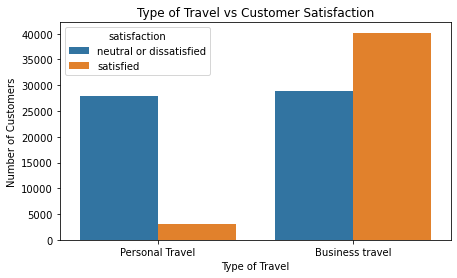

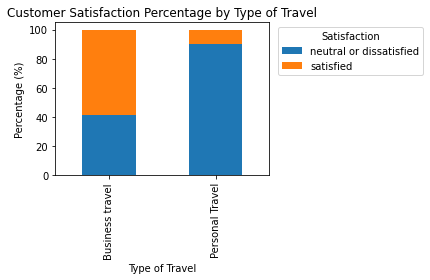

In [66]:
# ==========================================================
# BIVARIATE ANALYSIS
# Type of Travel vs Customer Satisfaction
#
# Business Question:
# Apakah pelanggan Business Travel memiliki
# tingkat kepuasan lebih tinggi dibandingkan
# Personal Travel?
#
# Tujuan:
# Menganalisis hubungan jenis perjalanan
# dengan Customer Satisfaction.
# ==========================================================

travel_sat = pd.crosstab(
    data['Type of Travel'],
    data['satisfaction']
)

display(travel_sat)

travel_percent = pd.crosstab(
    data['Type of Travel'],
    data['satisfaction'],
    normalize='index'
)*100

display(round(travel_percent,2))

# Countplot
plt.figure(figsize=(7,4))

sns.countplot(
    data=data,
    x='Type of Travel',
    hue='satisfaction'
)

plt.title('Type of Travel vs Customer Satisfaction')

plt.xlabel('Type of Travel')

plt.ylabel('Number of Customers')

plt.show()

# 100% Stacked Bar Chart
travel_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4)
)

plt.title('Customer Satisfaction Percentage by Type of Travel')

plt.ylabel('Percentage (%)')

plt.legend(title='Satisfaction',
           bbox_to_anchor=(1.02,1),
           loc='upper left')

plt.tight_layout()

plt.show()

satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,14610,33196
Eco,36625,8373
Eco Plus,5430,1766


satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,30.56,69.44
Eco,81.39,18.61
Eco Plus,75.46,24.54


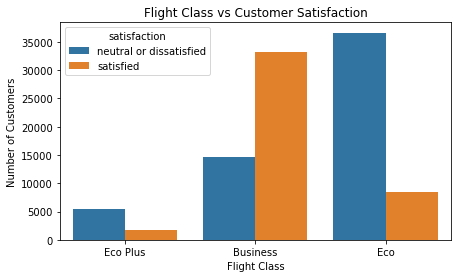

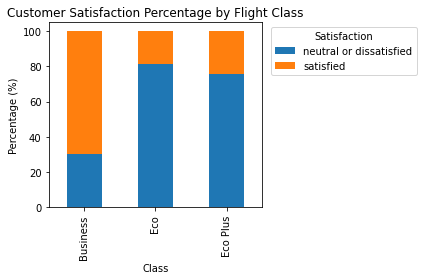

In [67]:
# ==========================================================
# BIVARIATE ANALYSIS
# Flight Class vs Customer Satisfaction
#
# Business Question:
# Apakah kelas penerbangan memengaruhi
# tingkat kepuasan pelanggan?
#
# Tujuan:
# Menganalisis hubungan Flight Class
# dengan Customer Satisfaction.
# ==========================================================

class_sat = pd.crosstab(
    data['Class'],
    data['satisfaction']
)

display(class_sat)

class_percent = pd.crosstab(
    data['Class'],
    data['satisfaction'],
    normalize='index'
)*100

display(round(class_percent,2))

# Countplot
plt.figure(figsize=(7,4))

sns.countplot(
    data=data,
    x='Class',
    hue='satisfaction'
)

plt.title('Flight Class vs Customer Satisfaction')

plt.xlabel('Flight Class')

plt.ylabel('Number of Customers')

plt.show()

# 100% Stacked Bar Chart
class_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4)
)

plt.title('Customer Satisfaction Percentage by Flight Class')

plt.ylabel('Percentage (%)')

plt.legend(title='Satisfaction',
           bbox_to_anchor=(1.02,1),
           loc='upper left')

plt.tight_layout()

plt.show()

satisfaction,neutral or dissatisfied,satisfied
Flight Distance Category,,
Long,1794,6179
Medium,16153,18130
Short,38718,19026


satisfaction,neutral or dissatisfied,satisfied
Flight Distance Category,,
Long,22.50,77.50
Medium,47.12,52.88
Short,67.05,32.95


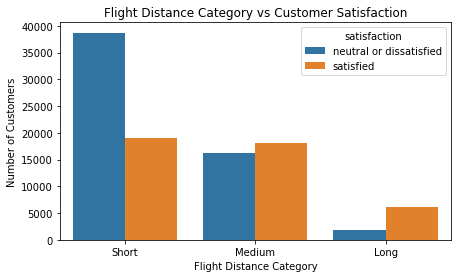

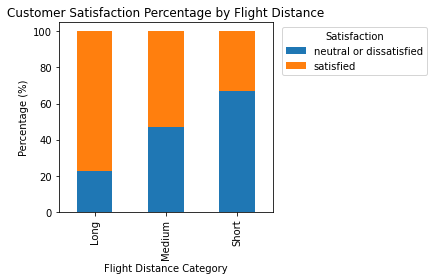

In [68]:
# ==========================================================
# BIVARIATE ANALYSIS
# Flight Distance Category vs Customer Satisfaction
#
# Business Question:
# Apakah jarak penerbangan berhubungan
# dengan tingkat kepuasan pelanggan?
#
# Tujuan:
# Mengidentifikasi hubungan kategori
# Flight Distance dengan Customer Satisfaction.
# ==========================================================

distance_sat = pd.crosstab(
    data['Flight Distance Category'],
    data['satisfaction']
)

display(distance_sat)

distance_percent = pd.crosstab(
    data['Flight Distance Category'],
    data['satisfaction'],
    normalize='index'
)*100

display(round(distance_percent,2))

# Countplot
plt.figure(figsize=(7,4))

sns.countplot(
    data=data,
    x='Flight Distance Category',
    hue='satisfaction'
)

plt.title('Flight Distance Category vs Customer Satisfaction')

plt.xlabel('Flight Distance Category')

plt.ylabel('Number of Customers')

plt.show()

# 100% Stacked Bar Chart
distance_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4)
)

plt.title('Customer Satisfaction Percentage by Flight Distance')

plt.ylabel('Percentage (%)')

plt.legend(title='Satisfaction',
           bbox_to_anchor=(1.02,1),
           loc='upper left')

plt.tight_layout()

plt.show()

In [69]:
# ==========================================================
# BIVARIATE ANALYSIS
# Average Service Rating by Customer Satisfaction
#
# Business Question:
# Layanan apa yang memiliki perbedaan penilaian
# antara pelanggan yang puas dan pelanggan yang tidak puas?
#
# Tujuan:
# Membandingkan rata-rata seluruh layanan
# berdasarkan tingkat kepuasan pelanggan.
# ==========================================================

service_columns = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

service_by_sat = (
    data
    .groupby('satisfaction')[service_columns]
    .mean()
    .T
)

display(service_by_sat)

satisfaction,neutral or dissatisfied,satisfied
Inflight wifi service,2.399559,3.159363
Departure/Arrival time convenient,3.129410,2.967232
Ease of Online booking,2.546722,3.029745
Gate location,2.975505,2.975862
Food and drink,2.959022,3.522741
Online boarding,2.656455,4.027876
Seat comfort,3.036989,3.967763
Inflight entertainment,2.894432,3.964578
On-board service,3.020754,3.854898
Leg room service,2.991159,3.820515


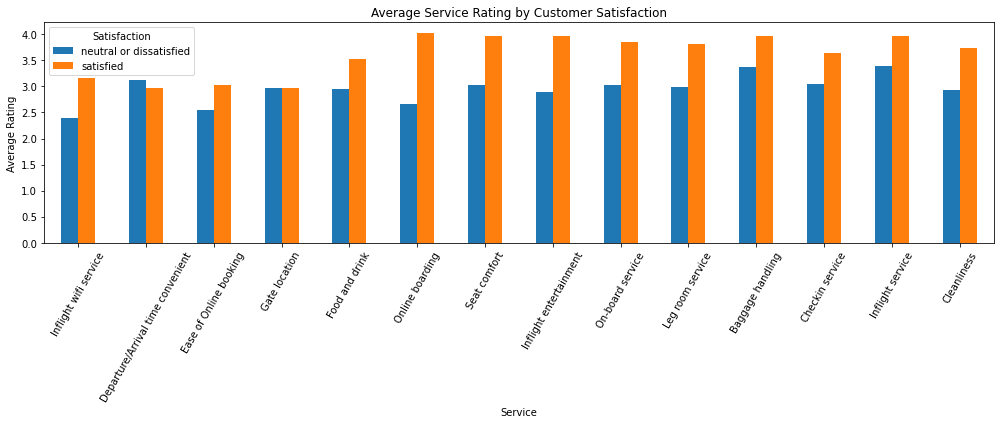

In [70]:
# ==========================================================
# VISUALIZATION
# Average Service Rating by Satisfaction
#
# Tujuan:
# Membandingkan rata-rata rating setiap layanan
# antara pelanggan yang puas dan tidak puas.
# ==========================================================

service_by_sat.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title('Average Service Rating by Customer Satisfaction')

plt.xlabel('Service')

plt.ylabel('Average Rating')

plt.xticks(rotation=60)

plt.legend(title='Satisfaction')

plt.tight_layout()

plt.show()

In [71]:
# ==========================================================
# SERVICE GAP ANALYSIS
#
# Tujuan:
# Menghitung selisih rata-rata rating layanan
# antara pelanggan puas dan pelanggan
# yang tidak puas.
# ==========================================================

service_gap = pd.DataFrame({

    'Gap':

    service_by_sat['satisfied']

    -

    service_by_sat['neutral or dissatisfied']

})

service_gap = service_gap.sort_values(
    by='Gap',
    ascending=False
)

display(service_gap)

,Gap
Online boarding,1.371421
Inflight entertainment,1.070146
Seat comfort,0.930773
On-board service,0.834144
Leg room service,0.829356
Cleanliness,0.809080
Inflight wifi service,0.759804
Checkin service,0.604459
Baggage handling,0.587125
Inflight service,0.579310


In [72]:
# ==========================================================
# TOP 5 SERVICE GAP
#
# Tujuan:
# Menampilkan lima layanan dengan
# selisih rating terbesar.
# ==========================================================

top_gap = service_gap.head(5)

display(top_gap)

,Gap
Online boarding,1.371421
Inflight entertainment,1.070146
Seat comfort,0.930773
On-board service,0.834144
Leg room service,0.829356


In [73]:
# ==========================================================
# BOTTOM 5 SERVICE GAP
#
# Tujuan:
# Menampilkan lima layanan dengan
# selisih rating terkecil.
# ==========================================================

bottom_gap = service_gap.tail(5)

display(bottom_gap)

,Gap
Inflight service,0.579310
Food and drink,0.563719
Ease of Online booking,0.483023
Gate location,0.000357
Departure/Arrival time convenient,-0.162178


<Figure size 720x432 with 0 Axes>

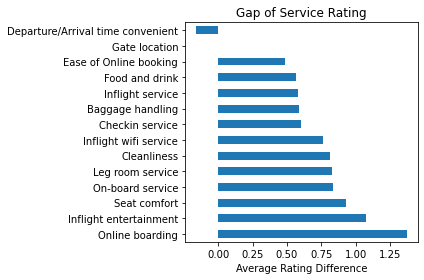

In [74]:
# ==========================================================
# SERVICE GAP VISUALIZATION
#
# Tujuan:
# Memvisualisasikan selisih rata-rata rating
# antara pelanggan puas dan tidak puas.
# ==========================================================

plt.figure(figsize=(10,6))

service_gap.plot(
    kind='barh',
    legend=False
)

plt.title('Gap of Service Rating')

plt.xlabel('Average Rating Difference')

plt.tight_layout()

plt.show()

In [75]:
# ==========================================================
# RANKING SERVICE GAP
#
# Tujuan:
# Memberikan peringkat layanan berdasarkan
# besar kecilnya selisih rating.
# ==========================================================

service_gap['Rank'] = range(
    1,
    len(service_gap)+1
)

display(service_gap)

,Gap,Rank
Online boarding,1.371421,1
Inflight entertainment,1.070146,2
Seat comfort,0.930773,3
On-board service,0.834144,4
Leg room service,0.829356,5
Cleanliness,0.809080,6
Inflight wifi service,0.759804,7
Checkin service,0.604459,8
Baggage handling,0.587125,9
Inflight service,0.579310,10


In [76]:
# ==========================================================
# RELATIVE SERVICE IMPROVEMENT (%)
#
# Tujuan:
# Menghitung persentase peningkatan rata-rata
# rating layanan antara pelanggan puas dan
# pelanggan yang tidak puas.
#
# Alasan:
# Tidak hanya melihat selisih absolut (Gap),
# tetapi juga melihat besarnya peningkatan
# secara relatif (%).
# ==========================================================

relative_gap = pd.DataFrame({

    'Neutral/Dissatisfied':
        service_by_sat['neutral or dissatisfied'],

    'Satisfied':
        service_by_sat['satisfied']

})

# Selisih absolut
relative_gap['Gap'] = (
    relative_gap['Satisfied']
    -
    relative_gap['Neutral/Dissatisfied']
)

# Persentase peningkatan
relative_gap['Gap (%)'] = (
    relative_gap['Gap']
    /
    relative_gap['Neutral/Dissatisfied']
) * 100

relative_gap = relative_gap.sort_values(
    by='Gap (%)',
    ascending=False
)

display(round(relative_gap,2))

,Neutral/Dissatisfied,Satisfied,Gap,Gap (%)
Online boarding,2.66,4.03,1.37,51.63
Inflight entertainment,2.89,3.96,1.07,36.97
Inflight wifi service,2.40,3.16,0.76,31.66
Seat comfort,3.04,3.97,0.93,30.65
Leg room service,2.99,3.82,0.83,27.73
On-board service,3.02,3.85,0.83,27.61
Cleanliness,2.94,3.75,0.81,27.55
Checkin service,3.04,3.65,0.60,19.87
Food and drink,2.96,3.52,0.56,19.05
Ease of Online booking,2.55,3.03,0.48,18.97


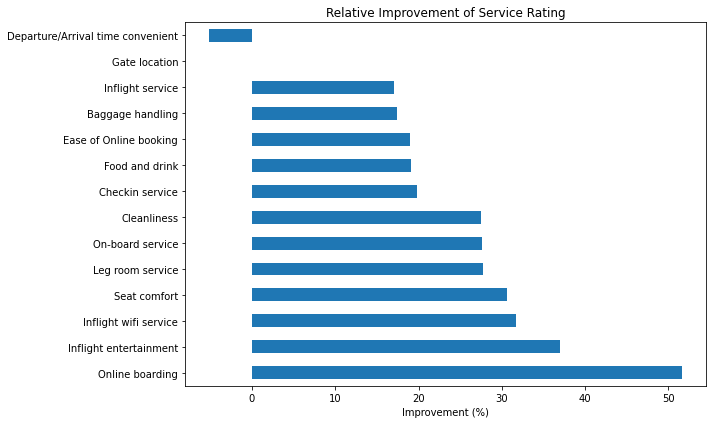

In [77]:
# ==========================================================
# VISUALIZATION
# Relative Service Improvement (%)
#
# Tujuan:
# Memvisualisasikan layanan yang mengalami
# peningkatan penilaian terbesar secara relatif.
# ==========================================================

plt.figure(figsize=(10,6))

relative_gap['Gap (%)'].plot(
    kind='barh'
)

plt.title('Relative Improvement of Service Rating')

plt.xlabel('Improvement (%)')

plt.tight_layout()

plt.show()

satisfaction,neutral or dissatisfied,satisfied
Delay Status,,
Delayed,27114,16840
On Time,29551,26495


satisfaction,neutral or dissatisfied,satisfied
Delay Status,,
Delayed,61.69,38.31
On Time,52.73,47.27


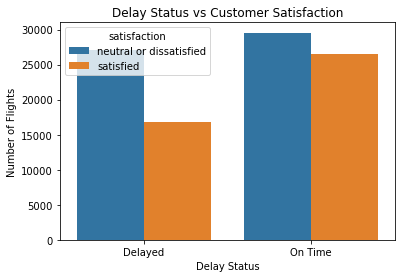

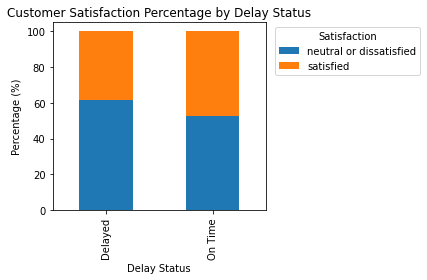

In [78]:
# ==========================================================
# BIVARIATE ANALYSIS
# Delay Status vs Customer Satisfaction
#
# Business Question:
# Apakah penerbangan yang mengalami
# keterlambatan memiliki tingkat kepuasan
# yang lebih rendah?
#
# Tujuan:
# Membandingkan tingkat kepuasan berdasarkan
# status keterlambatan penerbangan.
# ==========================================================

delay_sat = pd.crosstab(
    data['Delay Status'],
    data['satisfaction']
)

display(delay_sat)

delay_percent = pd.crosstab(
    data['Delay Status'],
    data['satisfaction'],
    normalize='index'
)*100

display(round(delay_percent,2))

# Countplot
plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x='Delay Status',
    hue='satisfaction'
)

plt.title('Delay Status vs Customer Satisfaction')

plt.xlabel('Delay Status')

plt.ylabel('Number of Flights')

plt.show()

# 100% Stacked Bar
delay_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4)
)

plt.title('Customer Satisfaction Percentage by Delay Status')

plt.ylabel('Percentage (%)')

plt.legend(
    title='Satisfaction',
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

satisfaction,neutral or dissatisfied,satisfied
Delay Severity,,
Minor Delay,12350,8670
Moderate Delay,10192,5627
On Time,29551,26495
Severe Delay,4572,2543


satisfaction,neutral or dissatisfied,satisfied
Delay Severity,,
Minor Delay,58.75,41.25
Moderate Delay,64.43,35.57
On Time,52.73,47.27
Severe Delay,64.26,35.74


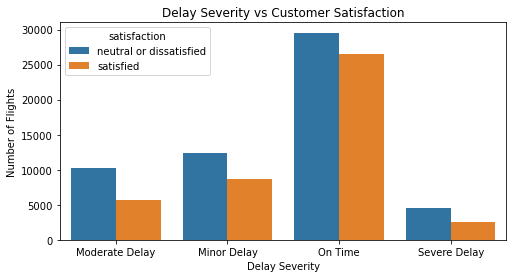

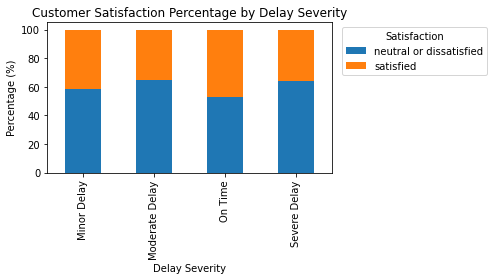

In [79]:
# ==========================================================
# BIVARIATE ANALYSIS
# Delay Severity vs Customer Satisfaction
#
# Business Question:
# Semakin tinggi tingkat keterlambatan,
# apakah kepuasan pelanggan semakin menurun?
#
# Tujuan:
# Membandingkan kepuasan pelanggan
# berdasarkan tingkat keparahan delay.
# ==========================================================

severity_sat = pd.crosstab(
    data['Delay Severity'],
    data['satisfaction']
)

display(severity_sat)

severity_percent = pd.crosstab(
    data['Delay Severity'],
    data['satisfaction'],
    normalize='index'
)*100

display(round(severity_percent,2))

# Countplot
plt.figure(figsize=(8,4))

sns.countplot(
    data=data,
    x='Delay Severity',
    hue='satisfaction'
)

plt.title('Delay Severity vs Customer Satisfaction')

plt.xlabel('Delay Severity')

plt.ylabel('Number of Flights')

plt.show()

# 100% Stacked Bar
severity_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(7,4)
)

plt.title('Customer Satisfaction Percentage by Delay Severity')

plt.ylabel('Percentage (%)')

plt.legend(
    title='Satisfaction',
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

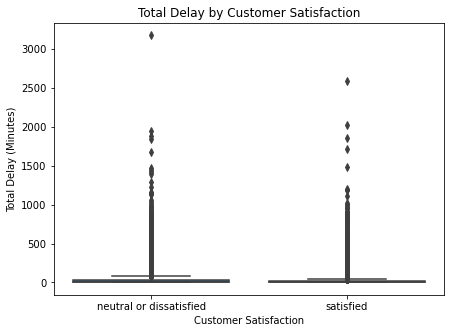

In [80]:
# ==========================================================
# BIVARIATE ANALYSIS
# Total Delay vs Customer Satisfaction
#
# Business Question:
# Apakah pelanggan yang tidak puas memiliki
# total delay yang lebih tinggi?
#
# Tujuan:
# Membandingkan distribusi Total Delay
# berdasarkan tingkat kepuasan.
# ==========================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=data,
    x='satisfaction',
    y='Total Delay'
)

plt.title('Total Delay by Customer Satisfaction')

plt.xlabel('Customer Satisfaction')

plt.ylabel('Total Delay (Minutes)')

plt.show()

In [81]:
# ==========================================================
# AVERAGE TOTAL DELAY
#
# Tujuan:
# Membandingkan rata-rata Total Delay
# antara pelanggan puas dan tidak puas.
# ==========================================================

delay_mean = (
    data
    .groupby('satisfaction')['Total Delay']
    .agg(['mean','median','std'])
)

display(round(delay_mean,2))

,mean,median,std
satisfaction,,,
neutral or dissatisfied,33.69,3.0,80.00
satisfied,25.35,1.0,70.98


In [82]:
# ==========================================================
# DELAY COMPARISON
#
# Tujuan:
# Membandingkan rata-rata delay
# berdasarkan Customer Satisfaction.
# ==========================================================

delay_compare = (
    data
    .groupby('satisfaction')[
        [
            'Departure Delay in Minutes',
            'Arrival Delay in Minutes',
            'Total Delay'
        ]
    ]
    .mean()
)

display(round(delay_compare,2))

,Departure Delay in Minutes,Arrival Delay in Minutes,Total Delay
satisfaction,,,
neutral or dissatisfied,16.50,17.19,33.69
satisfied,12.64,12.71,25.35


In [83]:
## 

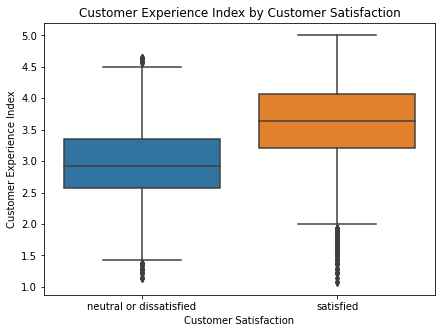

In [84]:
# ==========================================================
# BIVARIATE ANALYSIS
# Customer Experience Index vs Customer Satisfaction
#
# Business Question:
# Apakah pelanggan yang puas memiliki
# Customer Experience Index yang lebih tinggi?
#
# Tujuan:
# Membandingkan distribusi Customer Experience Index
# berdasarkan Customer Satisfaction.
# ==========================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=data,
    x='satisfaction',
    y='Customer Experience Index'
)

plt.title('Customer Experience Index by Customer Satisfaction')

plt.xlabel('Customer Satisfaction')

plt.ylabel('Customer Experience Index')

plt.show()

In [85]:
# ==========================================================
# AVERAGE CUSTOMER EXPERIENCE INDEX
#
# Tujuan:
# Membandingkan rata-rata Customer Experience Index
# berdasarkan Customer Satisfaction.
# ==========================================================

cei_summary = (
    data
    .groupby('satisfaction')['Customer Experience Index']
    .agg(['mean','median','std'])
)

display(round(cei_summary,2))

,mean,median,std
satisfaction,,,
neutral or dissatisfied,2.95,2.93,0.56
satisfied,3.62,3.64,0.59


satisfaction,neutral or dissatisfied,satisfied
Experience Level,,
High,1974,12718
Low,54691,30617


satisfaction,neutral or dissatisfied,satisfied
Experience Level,,
High,13.44,86.56
Low,64.11,35.89


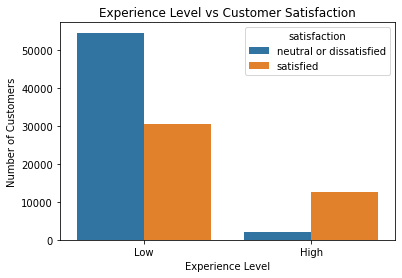

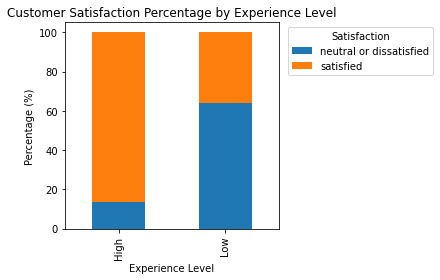

In [86]:
# ==========================================================
# EXPERIENCE LEVEL VS CUSTOMER SATISFACTION
#
# Business Question:
# Apakah pelanggan dengan Experience Level tinggi
# memiliki tingkat kepuasan yang lebih baik?
#
# Tujuan:
# Menganalisis hubungan Experience Level
# dengan Customer Satisfaction.
# ==========================================================

experience_sat = pd.crosstab(
    data['Experience Level'],
    data['satisfaction']
)

display(experience_sat)

experience_percent = (
    pd.crosstab(
        data['Experience Level'],
        data['satisfaction'],
        normalize='index'
    )*100
)

display(round(experience_percent,2))

# Countplot
plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x='Experience Level',
    hue='satisfaction'
)

plt.title('Experience Level vs Customer Satisfaction')

plt.xlabel('Experience Level')

plt.ylabel('Number of Customers')

plt.show()

# 100% Stacked Bar
experience_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4)
)

plt.title('Customer Satisfaction Percentage by Experience Level')

plt.ylabel('Percentage (%)')

plt.legend(
    title='Satisfaction',
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

satisfaction,neutral or dissatisfied,satisfied
Proxy NPS Category,,
Detractor,54691,30617
Passive,1974,12711
Promoter,0,7


satisfaction,neutral or dissatisfied,satisfied
Proxy NPS Category,,
Detractor,64.11,35.89
Passive,13.44,86.56
Promoter,0.00,100.00


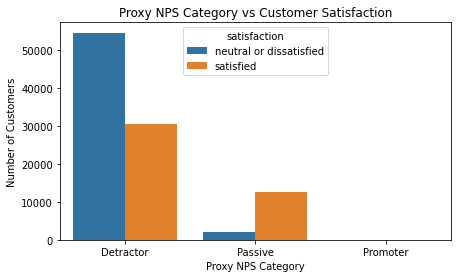

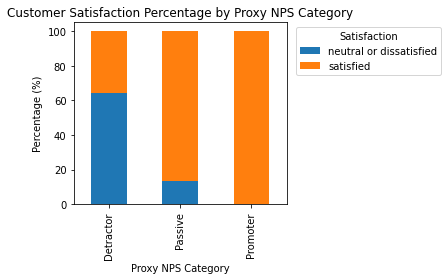

In [87]:
# ==========================================================
# PROXY NPS CATEGORY VS CUSTOMER SATISFACTION
#
# Business Question:
# Apakah pelanggan Promoter memiliki
# tingkat kepuasan lebih tinggi?
#
# Tujuan:
# Menganalisis hubungan Proxy NPS Category
# dengan Customer Satisfaction.
# ==========================================================

proxy_sat = pd.crosstab(
    data['Proxy NPS Category'],
    data['satisfaction']
)

display(proxy_sat)

proxy_percent = (
    pd.crosstab(
        data['Proxy NPS Category'],
        data['satisfaction'],
        normalize='index'
    )*100
)

display(round(proxy_percent,2))

# Countplot
plt.figure(figsize=(7,4))

sns.countplot(
    data=data,
    x='Proxy NPS Category',
    hue='satisfaction'
)

plt.title('Proxy NPS Category vs Customer Satisfaction')

plt.xlabel('Proxy NPS Category')

plt.ylabel('Number of Customers')

plt.show()

# 100% Stacked Bar
proxy_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4)
)

plt.title('Customer Satisfaction Percentage by Proxy NPS Category')

plt.ylabel('Percentage (%)')

plt.legend(
    title='Satisfaction',
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

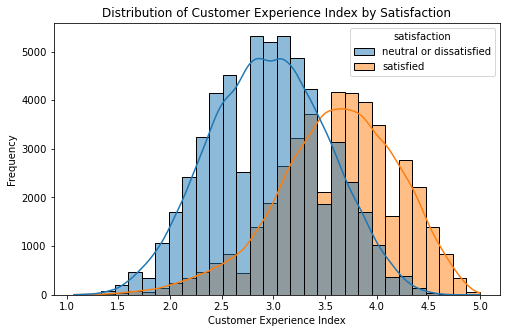

In [88]:
# ==========================================================
# CUSTOMER EXPERIENCE INDEX DISTRIBUTION
# BY CUSTOMER SATISFACTION
#
# Tujuan:
# Melihat distribusi CEI pada masing-masing
# kelompok Customer Satisfaction.
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x='Customer Experience Index',
    hue='satisfaction',
    kde=True,
    bins=30
)

plt.title('Distribution of Customer Experience Index by Satisfaction')

plt.xlabel('Customer Experience Index')

plt.ylabel('Frequency')

plt.show()

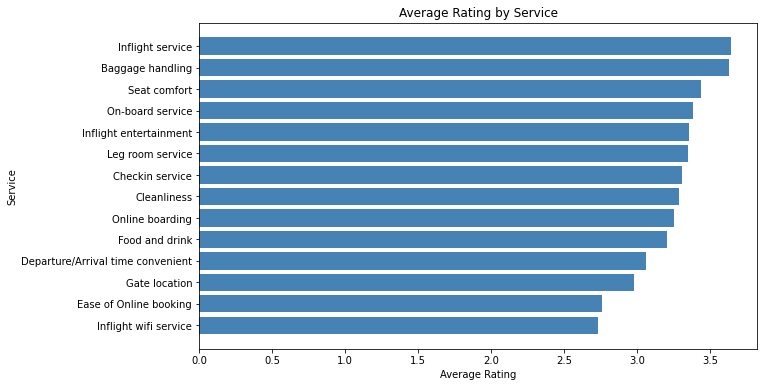

In [89]:
service_columns = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

avg_service = data[service_columns].mean().sort_values()

plt.figure(figsize=(10,6))

plt.barh(avg_service.index,
         avg_service.values,
         color='steelblue')

plt.title("Average Rating by Service")
plt.xlabel("Average Rating")
plt.ylabel("Service")

plt.show()

In [90]:
# ==========================================================
# STATISTICAL VALIDATION
#
# Import library yang digunakan untuk
# pengujian statistik.
# ==========================================================

from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
import numpy as np

In [91]:
# ==========================================================
# CHI-SQUARE TEST FUNCTION
#
# Tujuan:
# Menguji hubungan antara variabel kategorikal
# dengan Customer Satisfaction.
#
# Output:
# - Chi Square Statistic
# - P-value
# - Kesimpulan
# ==========================================================

def chi_square_test(column):

    contingency = pd.crosstab(
        data[column],
        data['satisfaction']
    )

    chi2, p, dof, expected = chi2_contingency(contingency)

    print("="*60)
    print(f"Variable : {column}")
    print(f"Chi-square Statistic : {chi2:.3f}")
    print(f"P-value : {p:.6f}")
    print(f"Degree of Freedom : {dof}")

    if p < 0.05:
        print("Conclusion : Significant Relationship")
    else:
        print("Conclusion : No Significant Relationship")

In [92]:
# ==========================================================
# CHI-SQUARE TEST
#
# Variabel kategorikal yang diuji
# ==========================================================

categorical_columns = [

    'Gender',

    'Customer Type',

    'Age Group',

    'Type of Travel',

    'Class',

    'Flight Distance Category',

    'Delay Status',

    'Delay Severity',

    'Experience Level',

    'Proxy NPS Category'

]

for col in categorical_columns:

    chi_square_test(col)

Variable : Gender
Chi-square Statistic : 18.003
P-value : 0.000022
Degree of Freedom : 1
Conclusion : Significant Relationship
Variable : Customer Type
Chi-square Statistic : 3514.673
P-value : 0.000000
Degree of Freedom : 1
Conclusion : Significant Relationship
Variable : Age Group
Chi-square Statistic : 6680.685
P-value : 0.000000
Degree of Freedom : 3
Conclusion : Significant Relationship
Variable : Type of Travel
Chi-square Statistic : 20191.073
P-value : 0.000000
Degree of Freedom : 1
Conclusion : Significant Relationship
Variable : Class
Chi-square Statistic : 25505.807
P-value : 0.000000
Degree of Freedom : 2
Conclusion : Significant Relationship
Variable : Flight Distance Category
Chi-square Statistic : 7599.230
P-value : 0.000000
Degree of Freedom : 2
Conclusion : Significant Relationship
Variable : Delay Status
Chi-square Statistic : 805.183
P-value : 0.000000
Degree of Freedom : 1
Conclusion : Significant Relationship
Variable : Delay Severity
Chi-square Statistic : 946.799


In [93]:
# ==========================================================
# CHI-SQUARE SUMMARY TABLE
#
# Tujuan:
# Membuat ringkasan hasil Chi-Square
# dalam bentuk tabel.
# ==========================================================

results = []

for col in categorical_columns:

    contingency = pd.crosstab(
        data[col],
        data['satisfaction']
    )

    chi2, p, dof, expected = chi2_contingency(contingency)

    results.append({

        'Variable': col,

        'Chi-square': round(chi2,2),

        'P-value': round(p,6),

        'Significant':

        'Yes'

        if p < 0.05

        else

        'No'

    })

chi_summary = pd.DataFrame(results)

display(chi_summary)

,Variable,Chi-square,P-value,Significant
0,Gender,18.00,0.000022,Yes
1,Customer Type,3514.67,0.000000,Yes
2,Age Group,6680.68,0.000000,Yes
3,Type of Travel,20191.07,0.000000,Yes
4,Class,25505.81,0.000000,Yes
5,Flight Distance Category,7599.23,0.000000,Yes
6,Delay Status,805.18,0.000000,Yes
7,Delay Severity,946.80,0.000000,Yes
8,Experience Level,13104.54,0.000000,Yes
9,Proxy NPS Category,13107.12,0.000000,Yes


In [94]:
# ==========================================================
# CRAMER'S V FUNCTION
#
# Tujuan:
# Mengukur kekuatan hubungan antara
# dua variabel kategorikal.
# ==========================================================

def cramers_v(confusion_matrix):

    chi2 = chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()

    r, k = confusion_matrix.shape

    return np.sqrt(

        chi2 /

        (n * (min(k-1, r-1)))

    )

In [95]:
# ==========================================================
# CRAMER'S V SUMMARY
#
# Tujuan:
# Menghitung kekuatan hubungan
# setiap variabel kategorikal.
# ==========================================================

effect_size = []

for col in categorical_columns:

    contingency = pd.crosstab(

        data[col],

        data['satisfaction']

    )

    effect_size.append({

        'Variable': col,

        'Cramers V':

        round(

            cramers_v(contingency),

            3

        )

    })

effect_summary = pd.DataFrame(effect_size)

effect_summary = effect_summary.sort_values(

    by='Cramers V',

    ascending=False

)

display(effect_summary)

,Variable,Cramers V
4,Class,0.505
3,Type of Travel,0.449
8,Experience Level,0.362
9,Proxy NPS Category,0.362
5,Flight Distance Category,0.276
2,Age Group,0.258
1,Customer Type,0.187
7,Delay Severity,0.097
6,Delay Status,0.090
0,Gender,0.013


## MULTIVARIATE ANALYSIS

## 1. Service Correlation

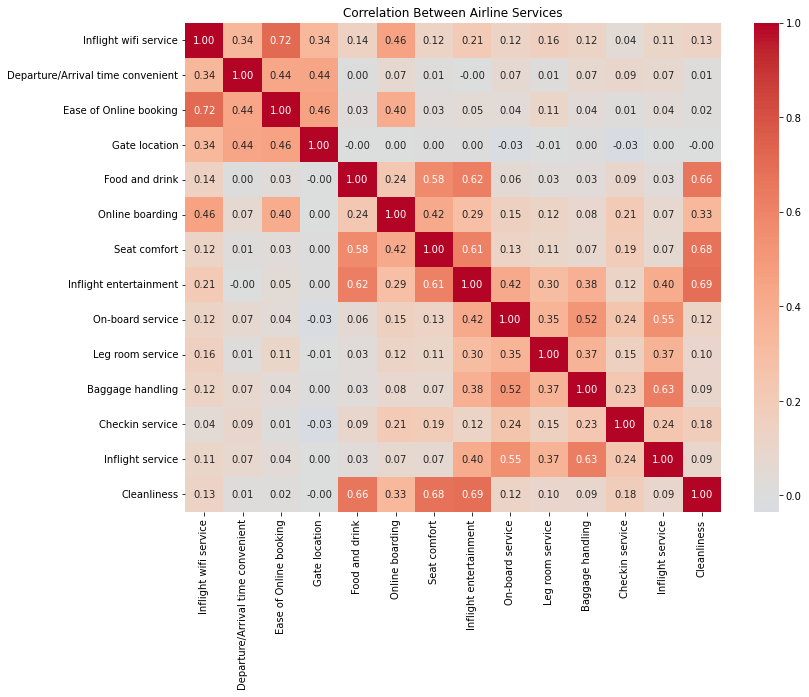

In [96]:
service_corr = data[service_columns].corr()

plt.figure(figsize=(12,9))

sns.heatmap(

    service_corr,

    annot=True,

    cmap='coolwarm',

    fmt=".2f",

    center=0

)

plt.title("Correlation Between Airline Services")

plt.show()

## 2. Operational Correlation

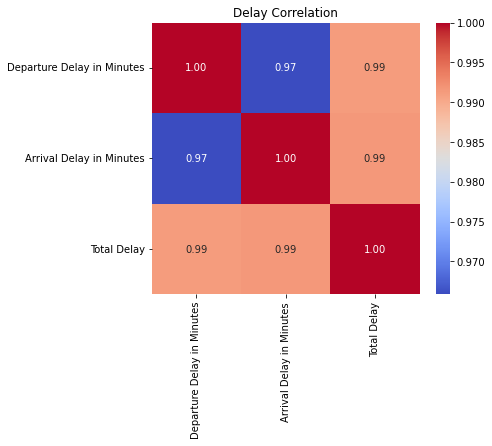

In [97]:
delay_columns = [

'Departure Delay in Minutes',

'Arrival Delay in Minutes',

'Total Delay'

]

delay_corr = data[delay_columns].corr()

plt.figure(figsize=(6,5))

sns.heatmap(

delay_corr,

annot=True,

fmt=".2f",

cmap='coolwarm'

)

plt.title("Delay Correlation")

plt.show()

## 3. Feature Engineering Correlation 

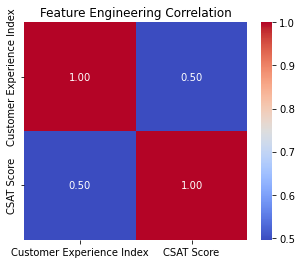

In [98]:
feature_columns = [

'Customer Experience Index',

'CSAT Score'

]

feature_corr = data[feature_columns].corr()

plt.figure(figsize=(5,4))

sns.heatmap(

feature_corr,

annot=True,

fmt=".2f",

cmap='coolwarm'

)

plt.title("Feature Engineering Correlation")

plt.show()

## DRIVER ANALYSIS

In [99]:
# ==========================================================
# Import library yang digunakan
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

In [100]:
# ==========================================================
# PREPARE DATA
#
# Tujuan:
# Menyiapkan data sebelum dilakukan
# Random Forest Classification.
# ==========================================================

model_data = data.copy()

In [101]:
# ==========================================================
# LABEL ENCODING
#
# Mengubah seluruh variabel kategorikal
# menjadi numerik.
# ==========================================================

le = LabelEncoder()

categorical = model_data.select_dtypes(include='object').columns

for col in categorical:

    model_data[col] = le.fit_transform(model_data[col])

In [102]:
# ==========================================================
# FEATURE DAN TARGET
#
# Menentukan variabel prediktor dan target.
# ==========================================================

X = model_data.drop(columns=[

    'id',

    'satisfaction',

    'CSAT Score',

    'Proxy NPS Category',

    'Experience Level'

])

y = model_data['satisfaction']# ==========================================================
# MEMBAGI DATA
#
# 80% Training
# 20% Testing
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [103]:
# ==========================================================
# RANDOM FOREST MODEL
#
# Melatih model Random Forest
# ==========================================================

rf = RandomForestClassifier(

    n_estimators=200,

    random_state=42
)

rf.fit(

    X_train,

    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [104]:
# ==========================================================
# FEATURE IMPORTANCE
#
# Mengidentifikasi variabel yang
# paling berpengaruh.
# ==========================================================

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf.feature_importances_

})

importance = importance.sort_values(

    by='Importance',

    ascending=False
)

display(importance.head(15))

,Feature,Importance
11,Online boarding,0.155454
6,Inflight wifi service,0.133864
29,Premium Customer,0.083406
3,Type of Travel,0.081633
4,Class,0.064145
22,Customer Experience Index,0.060339
13,Inflight entertainment,0.046832
8,Ease of Online booking,0.033502
15,Leg room service,0.028814
12,Seat comfort,0.027421


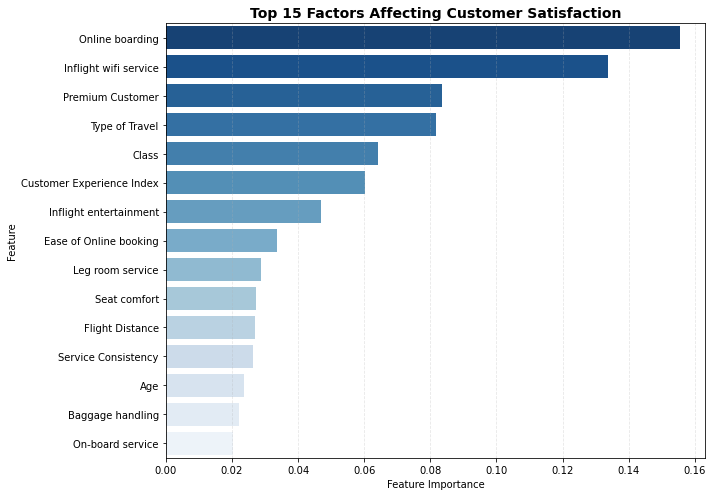

In [105]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature',
    palette='Blues_r'
)

plt.title('Top 15 Factors Affecting Customer Satisfaction',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

In [106]:
# FINAL DATASET INFORMATION

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 100000 non-null  int64  
 1   Gender                             100000 non-null  object 
 2   Customer Type                      100000 non-null  object 
 3   Age                                100000 non-null  int64  
 4   Type of Travel                     100000 non-null  object 
 5   Class                              100000 non-null  object 
 6   Flight Distance                    100000 non-null  int64  
 7   Inflight wifi service              100000 non-null  int64  
 8   Departure/Arrival time convenient  100000 non-null  int64  
 9   Ease of Online booking             100000 non-null  int64  
 10  Gate location                      100000 non-null  int64  
 11  Food and drink                     10000

In [107]:
# ==========================================================
# FINAL MISSING VALUE CHECK
# ==========================================================

data.isnull().sum()

id                                   0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
Customer Experience Index            0
Proxy NPS Category       

In [108]:
# EXPORT DATASET

data.to_csv(
    'Airline_Customer_Satisfaction_Final.csv',
    index=False
)

print("Dataset berhasil disimpan.")

Dataset berhasil disimpan.


In [109]:
importance.head(15)

,Feature,Importance
11,Online boarding,0.155454
6,Inflight wifi service,0.133864
29,Premium Customer,0.083406
3,Type of Travel,0.081633
4,Class,0.064145
22,Customer Experience Index,0.060339
13,Inflight entertainment,0.046832
8,Ease of Online booking,0.033502
15,Leg room service,0.028814
12,Seat comfort,0.027421


In [110]:
importance.to_csv("feature_importance.csv", index=False)